#### To perform the Bias vs Variance Tradeoff on Salary_Data


##### Step 1: Import all the necessary libraries

In [313]:
import  numpy   as  np
import  pandas  as  pd
import  matplotlib.pyplot   as  plt
import  seaborn             as  sns
import  pickle

from    sklearn.model_selection import train_test_split
from    sklearn.preprocessing   import StandardScaler, PolynomialFeatures
from    sklearn.linear_model    import LinearRegression
from    sklearn.pipeline        import Pipeline
from    sklearn.metrics         import mean_squared_error, mean_absolute_error, root_mean_squared_error, r2_score

#### Load the Dataset

In [314]:
df = pd.read_csv("Salary_Data.csv")

In [315]:
df

,YearsExperience,Salary
0,1.1,39343.0
1,1.3,46205.0
2,1.5,37731.0
3,2.0,43525.0
4,2.2,39891.0
5,2.9,56642.0
6,3.0,60150.0
7,3.2,54445.0
8,3.2,64445.0
9,3.7,57189.0


#### Divide the Dataset into independent and dependent variables

In [316]:
#### Independent variables

X = df.drop(columns = 'Salary',axis=1)

In [317]:
#### Dependent variables

Y = df[['Salary']]

In [318]:
print(X)

    YearsExperience
0               1.1
1               1.3
2               1.5
3               2.0
4               2.2
5               2.9
6               3.0
7               3.2
8               3.2
9               3.7
10              3.9
11              4.0
12              4.0
13              4.1
14              4.5
15              4.9
16              5.1
17              5.3
18              5.9
19              6.0
20              6.8
21              7.1
22              7.9
23              8.2
24              8.7
25              9.0
26              9.5
27              9.6
28             10.3
29             10.5


In [319]:
print(Y)

      Salary
0    39343.0
1    46205.0
2    37731.0
3    43525.0
4    39891.0
5    56642.0
6    60150.0
7    54445.0
8    64445.0
9    57189.0
10   63218.0
11   55794.0
12   56957.0
13   57081.0
14   61111.0
15   67938.0
16   66029.0
17   83088.0
18   81363.0
19   93940.0
20   91738.0
21   98273.0
22  101302.0
23  113812.0
24  109431.0
25  105582.0
26  116969.0
27  112635.0
28  122391.0
29  121872.0


#### Divide the independent and dependent variables into the training and testing data

In [320]:
from    sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(X,Y,test_size=0.2,random_state=42)

In [321]:
X_train

,YearsExperience
28,10.3
24,8.7
12,4.0
0,1.1
4,2.2
16,5.1
5,2.9
13,4.1
11,4.0
22,7.9


In [322]:
X_test

,YearsExperience
27,9.6
15,4.9
23,8.2
17,5.3
8,3.2
9,3.7


In [323]:
print("Shape of the input training data is:", X_train.shape)
print("Shape of the input testing  data is:", X_test.shape)

Shape of the input training data is: (24, 1)
Shape of the input testing  data is: (6, 1)


In [324]:
Y_train

,Salary
28,122391.0
24,109431.0
12,56957.0
0,39343.0
4,39891.0
16,66029.0
5,56642.0
13,57081.0
11,55794.0
22,101302.0


In [325]:
Y_test

,Salary
27,112635.0
15,67938.0
23,113812.0
17,83088.0
8,64445.0
9,57189.0


In [326]:
print("Shape of the output training data is:", Y_train.shape)
print("Shape of the output testing  data is:", Y_test.shape)

Shape of the output training data is: (24, 1)
Shape of the output testing  data is: (6, 1)


#### Create the Models for performing the Bias vs Variance Tradeoff

In [327]:
degrees = [1,5,15]

models = {}


for degree in degrees:
    model = Pipeline([
        ("scaler",StandardScaler())                    ,
        ("poly", PolynomialFeatures(degree=degree))    ,
        ("lin" , LinearRegression())
    ]
        
    )

    #### using the object train the model
    model.fit(X_train, Y_train)
    models[degree] = model

    #### predict the models
    Y_pred_train = model.predict(X_train)
    Y_pred_test  = model.predict(X_test)

    print(f"\n Degree : {degree}")
    print("Train MSE is:", mean_squared_error(Y_train, Y_pred_train))
    print("Test  MSE is:", mean_squared_error(Y_test , Y_pred_test))

    print("Train MAE is:", mean_absolute_error(Y_train, Y_pred_train))
    print("Test  MAE is:", mean_absolute_error(Y_test , Y_pred_test))


    print("Train RMSE is:", root_mean_squared_error(Y_train, Y_pred_train))
    print("Test  RMSE is:", root_mean_squared_error(Y_test , Y_pred_test))

    print("Train R2   is:", r2_score(Y_train, Y_pred_train))
    print("Test  R2   is:", r2_score(Y_test , Y_pred_test))


 Degree : 1
Train MSE is: 27102249.731261354
Test  MSE is: 49830096.85590834
Train MAE is: 4221.046734449734
Test  MAE is: 6286.453830757746
Train RMSE is: 5205.982110155715
Test  RMSE is: 7059.043621901506
Train R2   is: 0.9645401573418148
Test  R2   is: 0.9024461774180498

 Degree : 5
Train MSE is: 20109292.3901465
Test  MSE is: 46560480.97520227
Train MAE is: 3726.5688766660314
Test  MAE is: 5281.6025190544615
Train RMSE is: 4484.338567742906
Test  RMSE is: 6823.524087683891
Train R2   is: 0.9736895515614876
Test  R2   is: 0.9088471990427892

 Degree : 15
Train MSE is: 7376926.188930418
Test  MSE is: 59798229.2744895
Train MAE is: 2083.490750272836
Test  MAE is: 6940.059993261697
Train RMSE is: 2716.049739774737
Test  RMSE is: 7732.931480007404
Train R2   is: 0.9903482314363449
Test  R2   is: 0.8829312761276191


#### OBSERVATIONS:

1.  As the degree of the feature keeps on increasing, the training R2 score increases nut the testing R2 Score decreases.

2.   This condition leades to overfitting where the training accuracy of the model increases but the testing accuracy decreases.

In [328]:
#### Save the best model

best_models = models[5]

In [329]:
print(best_models)

Pipeline(steps=[('scaler', StandardScaler()),
                ('poly', PolynomialFeatures(degree=5)),
                ('lin', LinearRegression())])


In [330]:
#### Dump the best model

import joblib

joblib.dump(best_models, "model.pkl")

['model.pkl']

In [331]:
print("\n✅ Model saved as model.pkl")


✅ Model saved as model.pkl


d:\HDD DATA\New folder d\Generative_AI\1-Python\Machine_Learning\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
d:\HDD DATA\New folder d\Generative_AI\1-Python\Machine_Learning\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
d:\HDD DATA\New folder d\Generative_AI\1-Python\Machine_Learning\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


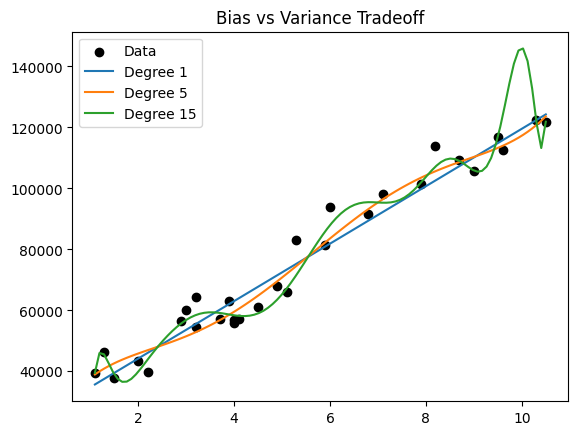

In [332]:
# Step 5: Visualization
X_plot = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)

plt.scatter(X, Y, color='black', label='Data')

for degree, model in models.items():
    y_plot = model.predict(X_plot)
    plt.plot(X_plot, y_plot, label=f"Degree {degree}")

plt.legend()
plt.title("Bias vs Variance Tradeoff")
plt.show()

#### OBSERVATIONS:

1. From the above graph, it is concluded that with increase in the number of years, the salary earned by the employee also increases.

2. With the increase in the number of degree, the best fit of line gets more and more fitted into the non linear data. This in turn leads to overfitting.